# You must have ran all 3 iterations of 441_data_download

# **Import Libraries**

In [ ]:
import os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import nibabel as nib
import torch
from transformers import CLIPTokenizer, CLIPTextModel
from sklearn.model_selection import train_test_split, LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, r2_score

# **About Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define project path and subjects
data_path = "/content/drive/MyDrive/things_fmri_project"
subs = [1, 2, 3]

In [ ]:
# Load semantic features, voxel responses, and concept list

# Load semantic embeddings
X_common = np.load(os.path.join(data_path, "X_semantic_embeddings_clip.npy"))

# Load voxel-response matrices for all subjects
aligned_Y = {
    1: np.load(os.path.join(data_path, "Y_sub1_visual.npy")),
    2: np.load(os.path.join(data_path, "Y_sub2_visual.npy")),
    3: np.load(os.path.join(data_path, "Y_sub3_visual.npy"))
}

# Load shared concept list
common_concepts = pd.read_csv(os.path.join(data_path, "concept_list.csv")).iloc[:, 0].tolist()

print("X_common shape:", X_common.shape)
for sub in subs:
    print(f"Subject {sub} Y shape:", aligned_Y[sub].shape)

print("Number of concepts:", len(common_concepts))
print("First 5 concepts:", common_concepts[:5])

X_common shape: (720, 512)
Subject 1 Y shape: (720, 9840)
Subject 2 Y shape: (720, 9840)
Subject 3 Y shape: (720, 9840)
Number of concepts: 720
First 5 concepts: ['acorn', 'airbag', 'aircraft_carrier', 'airplane', 'alligator']


In [ ]:

# Load and align subject metadata

subject_data = {}

for sub in subs:
    meta_file = os.path.join(data_path, f"concepts_sub{sub}.csv")
    meta = pd.read_csv(meta_file)

    # Load trial counts if file exists
    trial_file = os.path.join(data_path, f"Y_sub{sub}_trial_counts.csv")
    if os.path.exists(trial_file):
        trial_counts = pd.read_csv(trial_file)
        if "n_trials" in trial_counts.columns:
            meta["n_trials"] = trial_counts["n_trials"]

    # Align metadata to the common concept order
    meta_aligned = meta.set_index("concept").loc[common_concepts].reset_index()

    subject_data[sub] = {
        "Y": aligned_Y[sub],
        "meta": meta,
        "meta_aligned": meta_aligned
    }

print("Metadata loaded and aligned successfully.")
for sub in subs:
    print(f"Subject {sub} aligned concepts:", subject_data[sub]["meta_aligned"]["concept"].head().tolist())

Metadata loaded and aligned successfully.
Subject 1 aligned concepts: ['acorn', 'airbag', 'aircraft_carrier', 'airplane', 'alligator']
Subject 2 aligned concepts: ['acorn', 'airbag', 'aircraft_carrier', 'airplane', 'alligator']
Subject 3 aligned concepts: ['acorn', 'airbag', 'aircraft_carrier', 'airplane', 'alligator']


In [ ]:
# Concept alignment

print("Common concepts (first 5):", common_concepts[:5])
print("Subject 1 aligned concepts:", subject_data[1]["meta_aligned"]["concept"].head().tolist())
print("Subject 2 aligned concepts:", subject_data[2]["meta_aligned"]["concept"].head().tolist())
print("Subject 3 aligned concepts:", subject_data[3]["meta_aligned"]["concept"].head().tolist())

print("\nShape check:")
print("X_common:", X_common.shape)
print("Y1:", aligned_Y[1].shape)
print("Y2:", aligned_Y[2].shape)
print("Y3:", aligned_Y[3].shape)

Common concepts (first 5): ['acorn', 'airbag', 'aircraft_carrier', 'airplane', 'alligator']
Subject 1 aligned concepts: ['acorn', 'airbag', 'aircraft_carrier', 'airplane', 'alligator']
Subject 2 aligned concepts: ['acorn', 'airbag', 'aircraft_carrier', 'airplane', 'alligator']
Subject 3 aligned concepts: ['acorn', 'airbag', 'aircraft_carrier', 'airplane', 'alligator']

Shape check:
X_common: (720, 512)
Y1: (720, 9840)
Y2: (720, 9840)
Y3: (720, 9840)


In [ ]:
# Build semantic feature table

emb_cols = [f"emb_{i:03d}" for i in range(X_common.shape[1])]

X_df = pd.DataFrame(X_common, columns=emb_cols)
X_df.insert(0, "concept", common_concepts)

print("Semantic feature table shape:", X_df.shape)
X_df.head()

Semantic feature table shape: (720, 513)


,concept,emb_000,emb_001,emb_002,emb_003,emb_004,emb_005,emb_006,emb_007,emb_008,...,emb_502,emb_503,emb_504,emb_505,emb_506,emb_507,emb_508,emb_509,emb_510,emb_511
0,acorn,0.501031,0.145697,0.771741,4.599084,-8.928449,0.830962,1.063971,1.081408,-0.579525,...,-0.090047,0.510678,-0.071930,-0.035306,0.225743,0.590676,-0.125843,-0.188565,0.391153,-0.654546
1,airbag,-0.306758,-0.934341,-0.554644,2.686470,-6.370815,0.330022,0.149815,0.421487,-0.245054,...,0.114625,-0.567537,-0.760789,0.066275,0.746047,-0.288629,0.326504,-0.018442,0.193873,0.004722
2,aircraft_carrier,0.791500,0.042812,-0.242637,2.380142,-1.217377,-0.163752,0.470121,0.299325,0.652824,...,-0.855098,-0.393767,-0.310049,0.176702,0.262830,0.537258,-0.979554,0.134861,0.251338,-0.310299
3,airplane,0.487077,0.818722,-0.238785,1.832009,-3.179487,0.421172,0.243501,0.312598,-0.346770,...,-0.109491,-1.441807,-0.567992,0.271214,0.755329,-0.210262,-0.704701,2.717020,0.393324,-1.320682
4,alligator,0.210443,-0.016436,-0.011435,4.249550,-8.811866,0.316233,0.356669,-0.154716,0.062024,...,0.012913,-0.209606,-0.415235,-0.114570,0.373318,-0.276712,-0.334955,1.323416,0.130562,0.206950


In [ ]:
# Build dataframe for data analysis

eda_tables = []

for sub in subs:
    Y_sub = aligned_Y[sub]
    meta = subject_data[sub]["meta_aligned"][["concept", "n_trials"]].copy()

    eda_df = meta.merge(X_df, on="concept", how="left")
    eda_df["subject"] = sub

    # Brain-response summary columns
    eda_df["y_mean"] = Y_sub.mean(axis=1)
    eda_df["y_std"] = Y_sub.std(axis=1)
    eda_df["y_min"] = Y_sub.min(axis=1)
    eda_df["y_max"] = Y_sub.max(axis=1)
    eda_df["y_abs_mean"] = np.abs(Y_sub).mean(axis=1)
    eda_df["y_l2_norm"] = np.linalg.norm(Y_sub, axis=1)

    eda_tables.append(eda_df)

eda_all = pd.concat(eda_tables, ignore_index=True)

print("EDA dataframe shape:", eda_all.shape)
eda_all.head()

EDA dataframe shape: (2160, 521)


,concept,n_trials,emb_000,emb_001,emb_002,emb_003,emb_004,emb_005,emb_006,emb_007,...,emb_509,emb_510,emb_511,subject,y_mean,y_std,y_min,y_max,y_abs_mean,y_l2_norm
0,acorn,12,0.501031,0.145697,0.771741,4.599084,-8.928449,0.830962,1.063971,1.081408,...,-0.188565,0.391153,-0.654546,1,0.002835,0.019112,-0.071324,0.071915,0.015371,1.916584
1,airbag,12,-0.306758,-0.934341,-0.554644,2.686470,-6.370815,0.330022,0.149815,0.421487,...,-0.018442,0.193873,0.004722,1,0.002819,0.017647,-0.071242,0.065788,0.014083,1.772748
2,aircraft_carrier,12,0.791500,0.042812,-0.242637,2.380142,-1.217377,-0.163752,0.470121,0.299325,...,0.134861,0.251338,-0.310299,1,0.001685,0.024188,-0.091508,0.102550,0.019263,2.405222
3,airplane,12,0.487077,0.818722,-0.238785,1.832009,-3.179487,0.421172,0.243501,0.312598,...,2.717020,0.393324,-1.320682,1,0.000118,0.016103,-0.079594,0.068057,0.012734,1.597404
4,alligator,24,0.210443,-0.016436,-0.011435,4.249550,-8.811866,0.316233,0.356669,-0.154716,...,1.323416,0.130562,0.206950,1,0.000129,0.020103,-0.080301,0.075920,0.015912,1.994211


In [ ]:
# Data overview

print("Total rows:", len(eda_all))
print("Total columns:", eda_all.shape[1])
print("Unique concepts:", eda_all["concept"].nunique())

print("\nRows per subject:")
print(eda_all["subject"].value_counts().sort_index())

print("\nUnique concepts per subject:")
print(eda_all.groupby("subject")["concept"].nunique())

print("\nColumn types:")
print(eda_all.dtypes.value_counts())

Total rows: 2160
Total columns: 521
Unique concepts: 720

Rows per subject:
subject
1    720
2    720
3    720
Name: count, dtype: int64

Unique concepts per subject:
subject
1    720
2    720
3    720
Name: concept, dtype: int64

Column types:
float32    518
int64        2
object       1
Name: count, dtype: int64


The overall structure of the dataset. It confirms that the dataset contains all three subjects, each with 720 concepts, and helps verify that the data is balanced and correctly organized.

In [ ]:
# EDA setup

emb_cols = [c for c in eda_all.columns if c.startswith("emb_")]
y_summary_cols = ["y_mean", "y_std", "y_min", "y_max", "y_abs_mean", "y_l2_norm"]

# Use subject 1 only for semantic-feature EDA
X_eda = eda_all[eda_all["subject"] == 1][["concept"] + emb_cols].reset_index(drop=True)

# **Exploratory Data Analysis**

Check Missing values and duplicates

In [ ]:
missing_counts = eda_all.isnull().sum()
print("Total missing values:", missing_counts.sum())

print("Duplicate rows in eda_all:", eda_all.duplicated().sum())

dup_concept_subject = eda_all.duplicated(subset=["subject", "concept"]).sum()
print("Duplicate (subject, concept) rows:", dup_concept_subject)

Total missing values: 0
Duplicate rows in eda_all: 0
Duplicate (subject, concept) rows: 0


There are no missing values and thus our dataset is ready for analysis.

Numerical summary of  columns

count    2160.000000
mean       13.666667
std         4.150928
min        12.000000
25%        12.000000
50%        12.000000
75%        12.000000
max        24.000000
Name: n_trials, dtype: float64


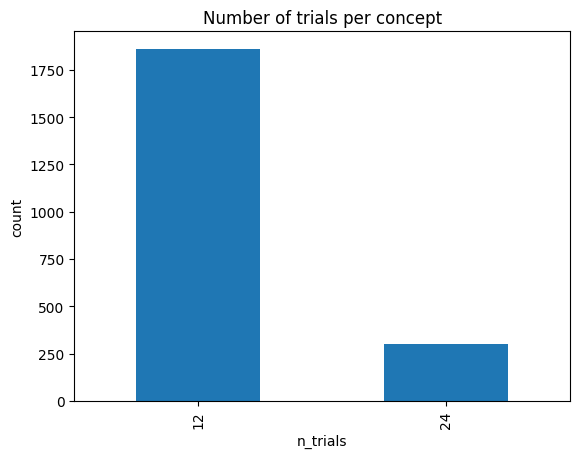

,count,mean,std,min,25%,50%,75%,max
n_trials,2160.0,13.666667,4.150928,12.000000,12.000000,1.200000e+01,12.000000,24.000000
y_mean,2160.0,0.000051,0.001621,-0.005278,-0.001023,-6.187543e-08,0.001069,0.006590
y_std,2160.0,0.020084,0.002556,0.012889,0.018659,1.994840e-02,0.021545,0.031196
y_min,2160.0,-0.085164,0.017450,-0.162452,-0.095213,-8.184961e-02,-0.072932,-0.046579
y_max,2160.0,0.080959,0.013100,0.045066,0.071891,7.985651e-02,0.088922,0.134493
y_abs_mean,2160.0,0.015983,0.002004,0.010272,0.014911,1.591201e-02,0.017140,0.024804
y_l2_norm,2160.0,1.998604,0.254509,1.278572,1.859122,1.984356e+00,2.145710,3.095646


In [ ]:
y_summary_cols = ["y_mean", "y_std", "y_min", "y_max", "y_abs_mean", "y_l2_norm"]

print(eda_all["n_trials"].describe())
eda_all["n_trials"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of trials per concept")
plt.xlabel("n_trials")
plt.ylabel("count")
plt.show()
display(eda_all[["n_trials"] + y_summary_cols].describe().T)

This table represents the number of trials per concept and the main brain-response summary values. It helps us understand the range, average, and spread of the target-side information.

The dataset is well-structured and consistent across all 2160 rows. Most concepts were averaged from 12 trials, while some had 24 trials, which explains the higher mean value of n_trials.

The brain-response summary values are small and centered near zero, which is expected for fMRI-style voxel responses. Measures like y_std, y_abs_mean, and y_l2_norm show that the response magnitudes are stable overall, with some concepts producing stronger activation patterns than others.

Subject-wise brain-response

In [ ]:
subject_summary = eda_all.groupby("subject")[y_summary_cols].agg(["mean", "std", "min", "max"])
display(subject_summary)

y_mean                                   y_std                      \
             mean       std       min       max      mean       std       min   
subject                                                                         
1        0.000760  0.001576 -0.004652  0.006518  0.020581  0.002497  0.013550   
2       -0.000857  0.001448 -0.005278  0.004702  0.018878  0.002161  0.012889   
3        0.000249  0.001393 -0.004543  0.006590  0.020793  0.002551  0.013380   

                      y_min            ...     y_max           y_abs_mean  \
              max      mean       std  ...       min       max       mean   
subject                                ...                                  
1        0.031196 -0.087018  0.015609  ...  0.048542  0.134092   0.016382   
2        0.027530 -0.073498  0.010165  ...  0.045066  0.126715   0.015093   
3        0.029369 -0.094976  0.018201  ...  0.051383  0.134493   0.016475   

                                      y_l2_norm                                
              std       min       max      mean       std       min       max  
subject                                                                        
1        0.001974  0.010828  0.024804  2.048697  0.249202  1.344387  3.095646  
2        0.001732  0.010272  0.022016  1.879896  0.215863  1.278572  2.737501  
3        0.001991  0.010676  0.023161  2.067219  0.253904  1.333922  2.918823  

[3 rows x 24 columns]

The subject-wise summary shows that all three participants have broadly similar brain-response patterns, which suggests the dataset is fairly consistent across subjects. Subject 2 has slightly lower average response magnitude (y_std, y_abs_mean, y_l2_norm) compared with subjects 1 and 3, but the differences are not very large.

Overall, this indicates that the data is balanced enough for subject-wise modeling and comparison. It also suggests that no subject appears to have severely abnormal or unusable response values.

Number of trials per concept

Distribution of target variables

In [ ]:
for col in y_summary_cols:
    plt.figure(figsize=(6, 4))
    eda_all[col].hist(bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

NameError: name 'y_summary_cols' is not defined

These histograms show how the target-side summary values are distributed across all concepts and subjects to understand understand whether the brain-response values are centered, spread out, or skewed.


The target summary distributions look smooth and mostly well-behaved, which suggests the brain-response summaries are stable across concepts. y_mean is centered close to zero, while y_std, y_abs_mean, and y_l2_norm show moderate spread, meaning different concepts produce different response strengths.

The y_min and y_max plots also show that voxel responses have a reasonable range without extreme irregular patterns. Overall, these plots suggest that the target-side data is suitable for modeling and does not show obvious distribution problems.

Subjects Comparisons(Boxplots)

<Figure size 600x400 with 0 Axes>

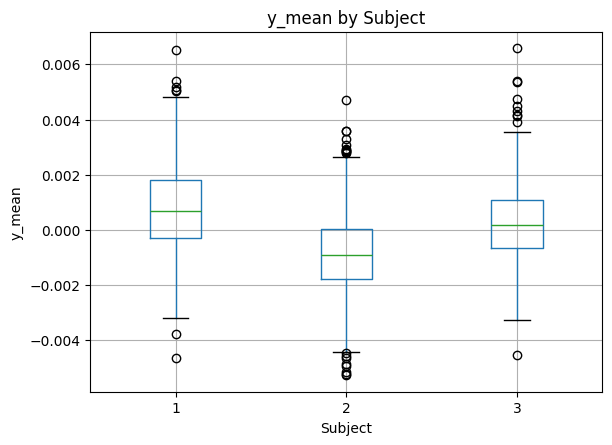

<Figure size 600x400 with 0 Axes>

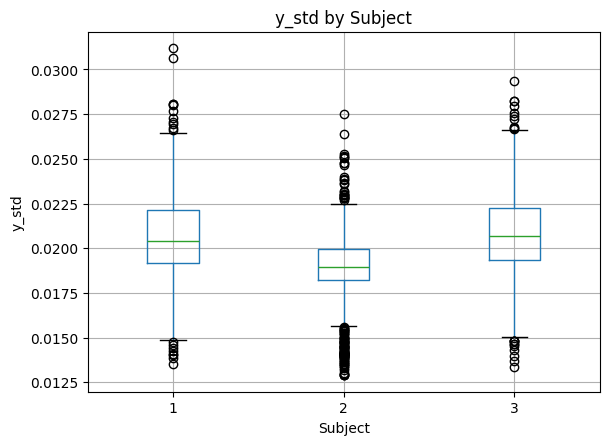

<Figure size 600x400 with 0 Axes>

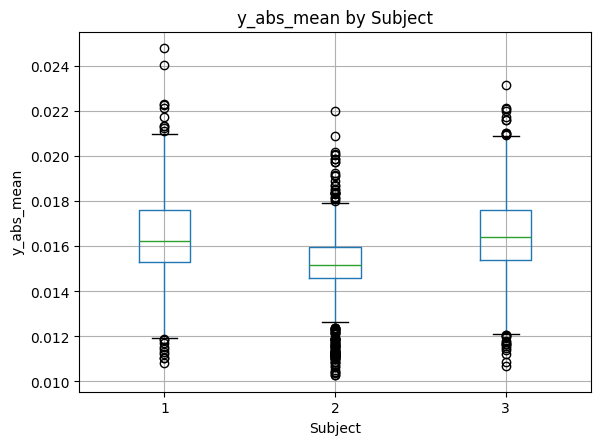

<Figure size 600x400 with 0 Axes>

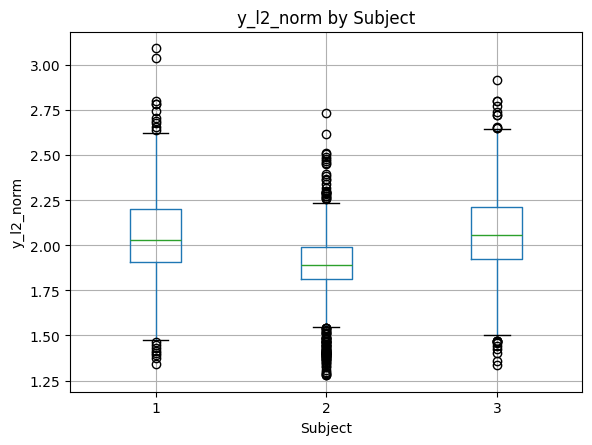

In [ ]:
for col in ["y_mean", "y_std", "y_abs_mean", "y_l2_norm"]:
    plt.figure(figsize=(6, 4))
    eda_all.boxplot(column=col, by="subject")
    plt.title(f"{col} by Subject")
    plt.suptitle("")
    plt.xlabel("Subject")
    plt.ylabel(col)
    plt.show()

These boxplots compare the subjects visually. They help us see whether one subject has systematically stronger, weaker, or more variable responses than the others.

Semantic feature variance

In [ ]:
feature_var = X_eda[emb_cols].var(axis=0)

print("Variance summary of semantic features:")
print(feature_var.describe())

print("\nTop 10 highest-variance semantic features:")
print(feature_var.sort_values(ascending=False).head(10))

print("\nTop 10 lowest-variance semantic features:")
print(feature_var.sort_values(ascending=True).head(10))

Variance summary of semantic features:
count    512.000000
mean       0.229780
std        0.430284
min        0.134843
25%        0.190633
50%        0.205014
75%        0.221890
max        9.888637
dtype: float64

Top 10 highest-variance semantic features:
emb_004    9.888637
emb_003    1.045623
emb_426    0.400224
emb_409    0.373970
emb_037    0.313198
emb_314    0.311706
emb_052    0.308593
emb_203    0.298234
emb_304    0.297833
emb_421    0.297075
dtype: float32

Top 10 lowest-variance semantic features:
emb_306    0.134843
emb_456    0.144564
emb_049    0.147223
emb_472    0.155639
emb_294    0.156207
emb_436    0.156624
emb_155    0.157774
emb_420    0.158994
emb_310    0.162338
emb_103    0.164247
dtype: float32


Spread of the input features. We found that the semantic embedding dimensions do not all have the same variance. The semantic features show different levels of variance, which means all embedding dimensions do not contribute on the same scale. Most features have moderate variance, but a few, especially emb_004, are much larger than the rest.

This is an important finding because it supports our decision to apply StandardScaler before modeling. In other words, feature scaling is needed so that no single semantic feature dominates the model just because of its larger numeric range.

Distribution of sample semantic features

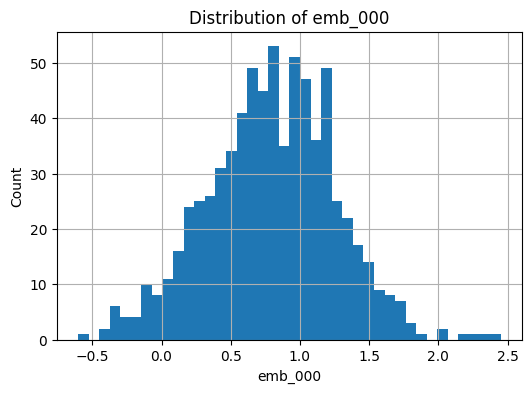

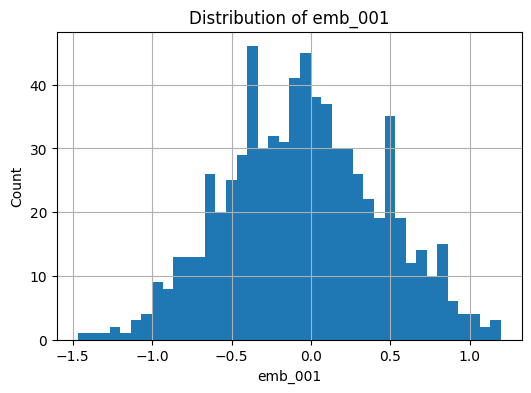

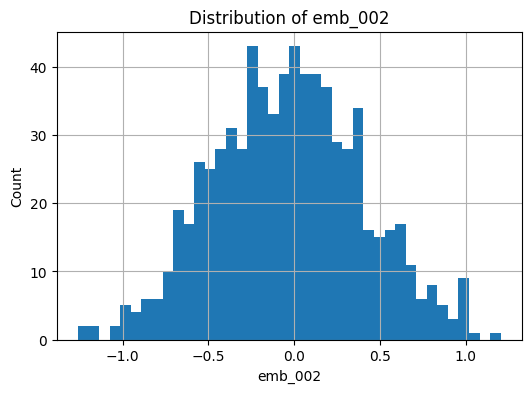

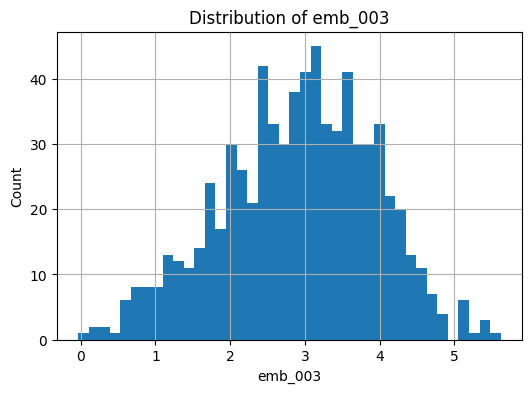

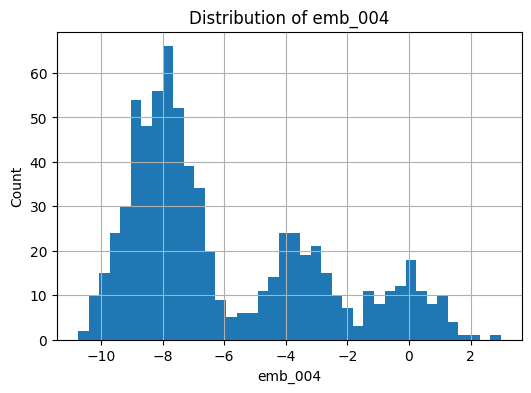

In [ ]:
sample_features = ["emb_000", "emb_001", "emb_002", "emb_003", "emb_004"]

for col in sample_features:
    plt.figure(figsize=(6, 4))
    X_eda[col].hist(bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

These plots show how individual semantic features are distributed. They help confirm that some features are on wider scales than others, which supports our decision to standardize the inputs.

PCA visualization of semantic features

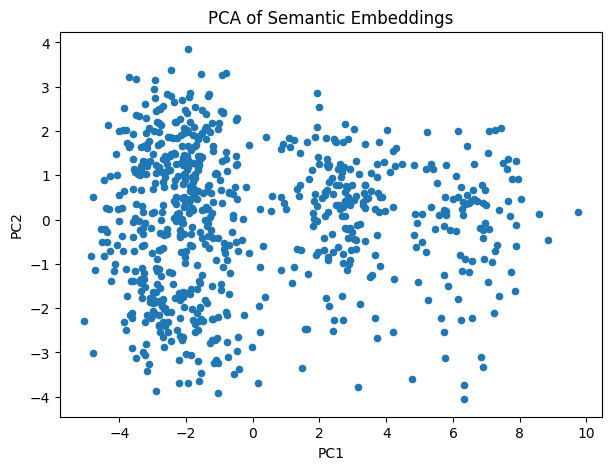

Explained variance ratio (PC1, PC2): [0.09803497 0.02146536]


In [ ]:
X_only = X_eda[emb_cols].values

pca_2 = PCA(n_components=2)
X_2d = pca_2.fit_transform(X_only)

plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=20)
plt.title("PCA of Semantic Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Explained variance ratio (PC1, PC2):", pca_2.explained_variance_ratio_)

This PCA plot gives a 2D view of the semantic feature space.

It helps us visualize how the concepts are spread in the embedding space and whether there is meaningful variation among them.

The first two PCA components explain about 11.95% of the total variance in the semantic features, with PC1 contributing much more than PC2.

This means the semantic feature space has some dominant structure, but the information is still spread across many dimensions.

So, while PCA helps us visualize the embeddings in 2D, it does not capture most of the information by itself.

This suggests that the full semantic feature set still contains important complexity for modeling.

PCA cumulative explained variance

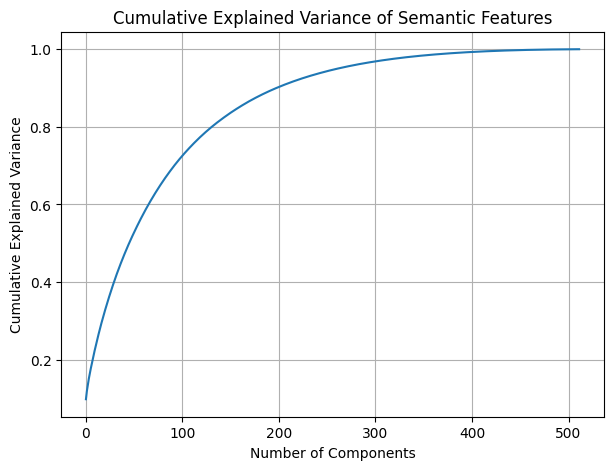

Components needed for 90% variance: 199
Components needed for 95% variance: 262
Components needed for 99% variance: 382


In [ ]:
pca_full = PCA()
pca_full.fit(X_only)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(7, 5))
plt.plot(cum_var)
plt.title("Cumulative Explained Variance of Semantic Features")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

for threshold in [0.90, 0.95, 0.99]:
    n_comp = np.argmax(cum_var >= threshold) + 1
    print(f"Components needed for {int(threshold * 100)}% variance: {n_comp}")

The PCA results show that the semantic embedding information is spread across many dimensions rather than concentrated in just a few. For example, we need 199 components to retain 90% of the variance and 262 components to retain 95%.

This means PCA can reduce the feature space, but not very aggressively without losing information.

It helps us make decision about if we want to use PCA for dimensionality-reduction in  the future.


 Strongest concepts by brain-response magnitude to interpret which concepts are associated with larger activation magnitudes.

In [ ]:
for sub in subs:
    print(f"\n SUBJECT {sub}(STRONGEST CONCEPTS):-")
    temp = eda_all[eda_all["subject"] == sub][["concept", "y_l2_norm", "y_abs_mean"]].copy()
    display(temp.sort_values("y_l2_norm", ascending=False).head(10))


 SUBJECT 1(STRONGEST CONCEPTS):-


,concept,y_l2_norm,y_abs_mean
396,microphone,3.095646,0.024804
311,helicopter,3.038605,0.024043
406,mop,2.804205,0.022304
375,locker,2.787783,0.022286
533,ruler,2.782813,0.022151
125,cauliflower,2.744806,0.021746
72,bottle,2.706439,0.021356
93,bumper,2.693097,0.021254
407,mosquito,2.679700,0.021361
570,slingshot,2.655664,0.021107



 SUBJECT 2(STRONGEST CONCEPTS):-


,concept,y_l2_norm,y_abs_mean
1316,stalagmite,2.737501,0.022016
763,bed,2.617804,0.020900
1189,ping-pong_table,2.514666,0.020206
1418,water_fountain,2.507674,0.020070
1053,jeans,2.492216,0.020088
806,brownie,2.482512,0.019889
742,baby,2.470913,0.019896
1102,mandolin,2.459374,0.019750
821,cactus,2.450675,0.019725
1143,noodle,2.398444,0.019239



 SUBJECT 3(STRONGEST CONCEPTS):-


,concept,y_l2_norm,y_abs_mean
1631,cup,2.918823,0.023161
2033,squeegee,2.803044,0.022114
1881,panda,2.802485,0.022157
1619,crayfish,2.771734,0.022025
2125,violin,2.738578,0.021633
1514,bowl,2.724006,0.021612
1798,leggings,2.723738,0.021729
2065,taco,2.658787,0.020988
1801,lemonade,2.652461,0.021047
1607,cookie,2.650028,0.021015


This output shows the highest-response concepts are different across subjects, which suggests that brain activation strength can vary from person to person even for the same type of object concepts.

At the same time, each subject clearly has a small group of concepts with noticeably stronger response magnitude than the rest. This tells us that some concepts are more strongly represented in the brain-response data and may be especially informative for modeling.

Cross-subject comparison using stronger summaries to understand whether the subjects show similar concept-level response magnitudes.

In [ ]:
for s1 in subs:
    for s2 in subs:
        if s1 < s2:
            corr_abs = np.corrcoef(
                np.abs(aligned_Y[s1]).mean(axis=1),
                np.abs(aligned_Y[s2]).mean(axis=1)
            )[0, 1]

            corr_l2 = np.corrcoef(
                np.linalg.norm(aligned_Y[s1], axis=1),
                np.linalg.norm(aligned_Y[s2], axis=1)
            )[0, 1]

            print(f"Subjects {s1} vs {s2} | abs-mean corr: {corr_abs:.4f} | l2-norm corr: {corr_l2:.4f}")

Subjects 1 vs 2 | abs-mean corr: 0.0420 | l2-norm corr: 0.0391
Subjects 1 vs 3 | abs-mean corr: -0.0237 | l2-norm corr: -0.0224
Subjects 2 vs 3 | abs-mean corr: 0.0803 | l2-norm corr: 0.0814


The cross-subject correlations are quite low, which means the overall response magnitudes are not strongly similar across participants. This suggests that brain-response patterns are somewhat subject-specific, even when the same set of concepts is used.

At the same time, the values are not exactly zero, so there is still a small amount of shared structure between some subjects, especially between subjects 2 and 3. Overall, this supports the idea that subject-wise modeling is more appropriate than assuming identical response behavior across all participants.

Voxel variance analysis


 SUBJECT 1 (VOXEL VARIANCE SUMMARY):- 
count    9840.000000
mean        0.000315
std         0.000050
min         0.000095
25%         0.000282
50%         0.000307
75%         0.000339
max         0.000774
dtype: float64


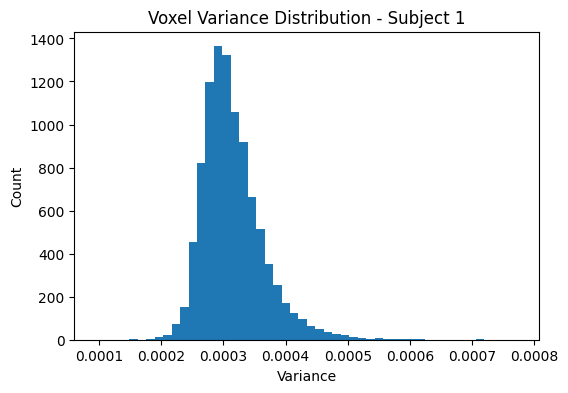


 SUBJECT 2 (VOXEL VARIANCE SUMMARY):- 
count    9840.000000
mean        0.000317
std         0.000041
min         0.000201
25%         0.000289
50%         0.000311
75%         0.000338
max         0.000666
dtype: float64


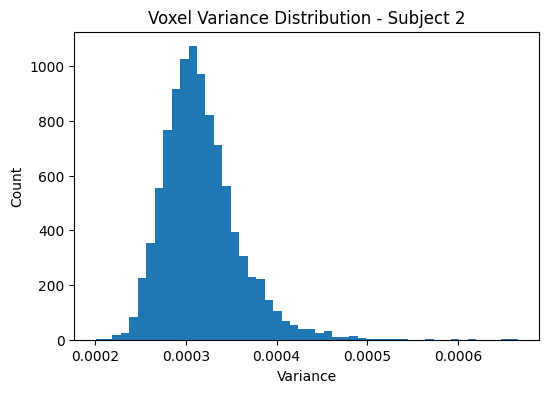


 SUBJECT 3 (VOXEL VARIANCE SUMMARY):- 
count    9840.000000
mean        0.000321
std         0.000061
min         0.000186
25%         0.000282
50%         0.000311
75%         0.000347
max         0.000980
dtype: float64


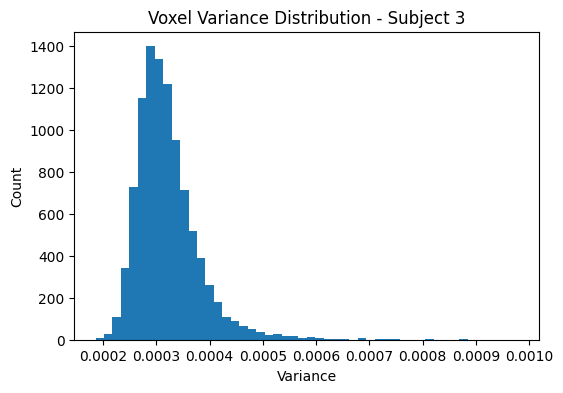

In [ ]:
for sub in subs:
    voxel_var = pd.Series(aligned_Y[sub].var(axis=0))

    print(f"\n SUBJECT {sub} (VOXEL VARIANCE SUMMARY):- ")
    print(voxel_var.describe())

    plt.figure(figsize=(6, 4))
    plt.hist(voxel_var, bins=50)
    plt.title(f"Voxel Variance Distribution - Subject {sub}")
    plt.xlabel("Variance")
    plt.ylabel("Count")
    plt.show()

The voxel variance summaries are very similar across all three subjects, which suggests that the target brain-response data is stable and consistently distributed. No subject shows unusually low or unusually high overall voxel variance, which is a good sign for data quality.

This also means the voxel-response targets are not obviously broken or degenerate, so they are suitable for modeling. At the same time, some voxels vary more than others, which could become useful later if voxel selection is explored as an optional experiment.

Highest and lowest variance voxels

In [ ]:
for sub in subs:
    voxel_var = pd.Series(aligned_Y[sub].var(axis=0))

    print(f"\n SUBJECT {sub} (TOP 10 HIGH-VARIANCE VOXELS) :-")
    print(voxel_var.sort_values(ascending=False).head(10))

    print(f"\n SUBJECT {sub} (TOP 10 LOW-VARIANCE VOXELS) :-")
    print(voxel_var.sort_values(ascending=True).head(10))


 SUBJECT 1 (TOP 10 HIGH-VARIANCE VOXELS) :-
594     0.000774
7529    0.000718
9445    0.000715
4392    0.000649
4958    0.000620
1112    0.000617
320     0.000606
9076    0.000604
6368    0.000599
6279    0.000590
dtype: float32

 SUBJECT 1 (TOP 10 LOW-VARIANCE VOXELS) :-
470     0.000095
6887    0.000140
7371    0.000149
1803    0.000153
8636    0.000179
5378    0.000181
2676    0.000182
9594    0.000185
3868    0.000187
3430    0.000191
dtype: float32

 SUBJECT 2 (TOP 10 HIGH-VARIANCE VOXELS) :-
5028    0.000666
8907    0.000650
8906    0.000618
4966    0.000615
6894    0.000596
9113    0.000571
7762    0.000541
240     0.000535
6895    0.000534
1272    0.000528
dtype: float32

 SUBJECT 2 (TOP 10 LOW-VARIANCE VOXELS) :-
7871    0.000201
8529    0.000208
8528    0.000215
8823    0.000217
9364    0.000219
8321    0.000220
8856    0.000220
1674    0.000220
8857    0.000220
9018    0.000220
dtype: float32

 SUBJECT 3 (TOP 10 HIGH-VARIANCE VOXELS) :-
1735    0.000980
9415    0.000884
444

This output highlights the most and least variable voxels. It  shows that some voxels respond much more variably across concepts than others, while a few remain relatively stable. The spread between the highest-variance and lowest-variance voxels confirms that not all target dimensions contribute equally to the data.

At the same time, this pattern appears across all three subjects, which suggests the voxel-response structure is meaningful and not random. These results support keeping all voxels for the main baseline model, while also showing that variance-based voxel selection could be explored later as an optional extension.

# **Feature Engineering**

Method : "StandardScaler" only on "Input features (X)" and thus all 512 semantic features.

Note :
Keep all 9840 voxel responses "Target (Y)" unchanged and also No PCA and NO feature dropping.

Feature Scaling Steps and Rules

Important rule: fit scaler on X_train only, then transform X_train and X_test to avoids data leakage from the test set.


We do not fit the scaler on the full dataset now because that would leak information from the test set. The actual scaling will happen after the train/test split.

# **Data train/test split**

Create one common 75/25 concept split

In [ ]:
from sklearn.model_selection import train_test_split


# Total concept indices: 0 to 719
concept_names = np.array(common_concepts)
concept_indices = np.arange(len(concept_names))

# One common split for all subjects
train_idx, test_idx = train_test_split(
    concept_indices,
    test_size=0.25,
    random_state=42,
    shuffle=True
)

print("Total concepts:", len(concept_indices))
print("Training concepts:", len(train_idx))
print("Testing concepts:", len(test_idx))
print("First 10 training indices:", train_idx[:10])
print("First 10 testing indices:", test_idx[:10])

Total concepts: 720
Training concepts: 540
Testing concepts: 180
First 10 training indices: [265 356 469 667 449 432 619 256 353 439]
First 10 testing indices: [340 290  54 198 453  65  63 145 292 390]


Creates one shared concept-level split for the whole dataset.

Here, we devided 720 concepts into 540 training concepts and 180 testing concepts, and this same split will be reused for all three subjects.

Create train/test semantic input matrices

In [ ]:
X_base = X_common.astype(np.float32)
X_train = X_base[train_idx]
X_test = X_base[test_idx]

train_concepts = concept_names[train_idx]
test_concepts = concept_names[test_idx]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("First 5 training concepts:", train_concepts[:5])
print("First 5 testing concepts:", test_concepts[:5])

X_train shape: (540, 512)
X_test shape: (180, 512)
First 5 training concepts: ['garlic' 'lectern' 'ping-pong_table' 'trowel' 'pea']
First 5 testing concepts: ['kazoo' 'groundhog' 'birdcage' 'desk' 'pecan']


Here, we applied the common split to the semantic input matrix X_base.

Our result is a training input matrix with 540 concepts and a testing input matrix with 180 unseen concepts.

Apply the same split to all three subjects

In [ ]:
Y_subjects = {
    1: aligned_Y[1].astype(np.float32),
    2: aligned_Y[2].astype(np.float32),
    3: aligned_Y[3].astype(np.float32),
}
Y_train_subjects = {}
Y_test_subjects = {}

for sub in Y_subjects:
    Y_train_subjects[sub] = Y_subjects[sub][train_idx]
    Y_test_subjects[sub] = Y_subjects[sub][test_idx]

    print(f"Subject {sub}:")
    print("  Y_train shape:", Y_train_subjects[sub].shape)
    print("  Y_test shape :", Y_test_subjects[sub].shape)

Subject 1:
  Y_train shape: (540, 9840)
  Y_test shape : (180, 9840)
Subject 2:
  Y_train shape: (540, 9840)
  Y_test shape : (180, 9840)
Subject 3:
  Y_train shape: (540, 9840)
  Y_test shape : (180, 9840)


Here we applied the exact same concept split to the voxel-response target matrices of all three subjects. This ensures that all subjects are trained and tested on the same concepts, which makes the comparison fair and consistent.

Check alignment after split

In [ ]:
print("First 5 training concepts:", train_concepts[:5])
print("First 5 testing concepts:", test_concepts[:5])

print("\nShape check:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

for sub in Y_subjects:
    print(f"Subject {sub} [Y_train] : {Y_train_subjects[sub].shape}, [Y_test]: {Y_test_subjects[sub].shape}")

First 5 training concepts: ['garlic' 'lectern' 'ping-pong_table' 'trowel' 'pea']
First 5 testing concepts: ['kazoo' 'groundhog' 'birdcage' 'desk' 'pecan']

Shape check:
X_train: (540, 512)
X_test : (180, 512)
Subject 1 [Y_train] : (540, 9840), [Y_test]: (180, 9840)
Subject 2 [Y_train] : (540, 9840), [Y_test]: (180, 9840)
Subject 3 [Y_train] : (540, 9840), [Y_test]: (180, 9840)


Here, we verified that the 75/25 concept split was correctly applied across the whole dataset. The semantic input matrix was divided into 540 training concepts and 180 testing concepts, and the same split was consistently applied to all three subjects’ voxel-response matrices.

Fit scaler on training data only

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

print("Scaler fitted on X_train only.")
print("Number of features learned by scaler:", len(scaler.mean_))

Scaler fitted on X_train only.
Number of features learned by scaler: 512


Here, we use StandardScaler because the semantic input features have different numeric scales, and scaling helps make them comparable for model training.

Moreover, we fit the scaler using only the training input data because it prevents test-set information from leaking into the training process.

Transform train and test inputs

In [ ]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

X_train_scaled shape: (540, 512)
X_test_scaled shape : (180, 512)


This output shows that the number of features remains the same at 512.
It also presentations that the split structure is preserved after scaling, with 540 concepts in the training set and 180 concepts in the testing set.

Scaling results on training data

In [ ]:
train_feature_means = X_train_scaled.mean(axis=0)
train_feature_stds = X_train_scaled.std(axis=0)

print("Mean of scaled training features (first 10):")
print(np.round(train_feature_means[:10], 4))

print("\nStd of scaled training features (first 10):")
print(np.round(train_feature_stds[:10], 4))

Mean of scaled training features (first 10):
[ 0.  0. -0.  0.  0. -0. -0. -0.  0. -0.]

Std of scaled training features (first 10):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


This output shows that the feature means are approximately 0 and the standard deviations are approximately 1, which confirms that the semantic input features are now standardized and are on common scale, so no single feature will dominate the model just because of its larger numeric range.

Comparison of  before and after scaling

In [ ]:
print("Before scaling:")
print("X_train mean (first 5 features):", np.round(X_train.mean(axis=0)[:5], 4))
print("X_train std  (first 5 features):", np.round(X_train.std(axis=0)[:5], 4))

print("\nAfter scaling:")
print("X_train_scaled mean (first 5 features):", np.round(X_train_scaled.mean(axis=0)[:5], 4))
print("X_train_scaled std  (first 5 features):", np.round(X_train_scaled.std(axis=0)[:5], 4))

Before scaling:
X_train mean (first 5 features): [ 0.808  -0.0486 -0.0427  2.9114 -6.0663]
X_train std  (first 5 features): [0.4602 0.4842 0.4358 1.0005 3.109 ]

After scaling:
X_train_scaled mean (first 5 features): [ 0.  0. -0.  0.  0.]
X_train_scaled std  (first 5 features): [1. 1. 1. 1. 1.]


This output clearly shows the effect of feature scaling.

Before scaling, the semantic features had different means and standard deviations, which means they were on different numeric scales.

After applying StandardScaler, the training features are centered around 0 with standard deviation 1.

We applied StandardScaler by fitting it only on the training data and then using the same scaler to transform both the training and testing sets.

This prevents data leakage because no information from the test set is used during feature scaling. As a result, the model is evaluated more fairly on truly unseen data.

Keep raw and scaled dataset separate (For Model Building)

In [ ]:
X_versions = {
    "raw_train": X_train,
    "raw_test": X_test,
    "scaled_train": X_train_scaled,
    "scaled_test": X_test_scaled,
}

print("Prepared X versions for modeling:")
for name, arr in X_versions.items():
    print(name, arr.shape)

Prepared X versions for modeling:
raw_train (540, 512)
raw_test (180, 512)
scaled_train (540, 512)
scaled_test (180, 512)


Here, we have separated data in two versions which are raw and scaled versions of the input data were saved for later machine learning  because it will allow us to compare models with feature engineering against models without feature engineering using the same train/test split.

The scaled inputs will be used for FE-based Ridge and Lasso models, while the raw inputs will be used for the direct Ridge baseline without FE to understand how FE can make impact on ML models.

# Machine Learning

# **Model Building**

# **Model Evaluation**

# **Model Comparison**